# PMSM FCS-MPC dq current control

In this tutorial, we apply a finite-control set (FCS) model predictive control (MPC) approach to realize current control of a permanent magnet synchronous motor (PMSM) in rotor field-oriented coordinates.
Unlike continuous-control set (CCS) MPC, FCS-MPC directly evaluates a finite set of switching states to optimize the control input based on a cost function over a prediction horizon.

![MPC2](img/mpc_structure.png)

![MPC1](img/mpc_scheme.png)

With the help of the system model the output variables are calculated. By minimizing a cost function, the optimizer determines the optimal control variables for the following N time steps, the so-called prediction horizon. The first manipulated variable is switched on and then the system outputs are measured. When calculating the manipulated variables, the manipulated variable limits are explicitly taken into account.

![Limits](img/voltage_limits.png)
The quadratic control error area is used as the cost function. Since the control is performed in the rotating dq-coordinates, the voltage limits, which have the shape of a hexagon, are time-variant. The optimization problem is solved iteratively using an Interior-Point Solver, which approximates the limits using barrier functions.

## Installation of the required toolboxes

In [1]:
!pip install -q git+https://github.com/upb-lea/gym-electric-motor

In [2]:
import numpy as np
import math
import matplotlib

import gym_electric_motor as gem
from gym_electric_motor.envs.motors import ActionType, ControlType, Motor, MotorType
from gym_electric_motor.physical_systems import ConstantSpeedLoad
from gym_electric_motor.reference_generators import MultipleReferenceGenerator, SwitchedReferenceGenerator, \
        TriangularReferenceGenerator, SinusoidalReferenceGenerator, StepReferenceGenerator
from gym_electric_motor.visualization.motor_dashboard import MotorDashboard
from gym_electric_motor.physical_systems.solvers import ScipySolveIvpSolver

## Definition of a general controller class

In [3]:
class Controller:

    @classmethod
    def make(cls, controller_type, environment, **controller_kwargs):
        assert controller_type in _controllers.keys(), f'Controller {controller_type} unknown'
        controller = _controllers[controller_type](environment, **controller_kwargs)
        return controller

    def control(self, state, reference):
        pass

    def reset(self):
        pass

## Definition of the MPC class

In [ ]:
class FCS_MPC(Controller):
    def __init__(self, environment, ph=1, ref_idx_q=0, ref_idx_d=1):
        # conversion of the coordinate systems  

        def clarke(abc):
            """abc → αβ transformation (3-phase to 2-phase)"""
            a, b, c = abc
            alpha = a - 0.5*b - 0.5*c  # = a (when a + b + c = 0)
            beta = (np.sqrt(3)/2)*b - (np.sqrt(3)/2)*c
            return np.array([alpha, beta]) * (2/3)  # Power-invariant version
        
        def park(alpha_beta, theta):
            """αβ → dq transformation"""
            alpha, beta = alpha_beta
            d = alpha * np.cos(theta) + beta * np.sin(theta)
            q = -alpha * np.sin(theta) + beta * np.cos(theta)
            return np.array([d, q])
        
       
        # Create transformation functions
        self._forward_transformation = lambda abc, eps: park(clarke(abc), eps)
        
    
        # indices
        self.ref_idx_i_q = ref_idx_q
        self.ref_idx_i_d = ref_idx_d
        self.i_sd_idx = environment.get_wrapper_attr('state_names').index('i_sd')
        self.i_sq_idx = environment.get_wrapper_attr('state_names').index('i_sq')
        self.u_a_idx = environment.get_wrapper_attr('state_names').index('u_a')
        self.u_b_idx = environment.get_wrapper_attr('state_names').index('u_b')
        self.u_c_idx = environment.get_wrapper_attr('state_names').index('u_c')
        self.u_sq_idx = environment.get_wrapper_attr('state_names').index('u_sq')
        self.u_sd_idx = environment.get_wrapper_attr('state_names').index('u_sd')
        self.omega_idx = environment.get_wrapper_attr('state_names').index('omega')
        self.epsilon_idx = environment.get_wrapper_attr('state_names').index('epsilon')

        # motor parameters
        self.tau = environment.get_wrapper_attr('physical_system').tau
        self.limits = environment.get_wrapper_attr('physical_system').limits
        self.l_q = environment.get_wrapper_attr('physical_system').electrical_motor.motor_parameter['l_q']
        self.l_d = environment.get_wrapper_attr('physical_system').electrical_motor.motor_parameter['l_d']
        self.psi_ = environment.get_wrapper_attr('physical_system').electrical_motor.motor_parameter['psi_p']
        self.r_s = environment.get_wrapper_attr('physical_system').electrical_motor.motor_parameter['r_s']
        self.p = environment.get_wrapper_attr('physical_system').electrical_motor.motor_parameter['p']
        self.ph_ = ph  # Prediction horizon (typically 1 for FCS-MPC)
        
        # Define the finite set of voltage vectors (for a 2-level inverter)
        # These are the 8 possible switching states (6 active + 2 zero vectors)
        self.voltage_vectors = [            
            (2/3, -1/3, -1/3),    # V1
            (1/3, 1/3, -2/3),      # V2
            (-1/3, 2/3, -1/3),     # V3
            (-2/3, 1/3, 1/3),      # V4
            (-1/3, -1/3, 2/3),    # V5
            (1/3, -2/3, 1/3),      # V6            
            (0, 0, 0),             # V0
            (0, 0, 0)        # V7
        ]
        
        # Scale vectors by maximum voltage
        self.voltage_vectors = [
            (v_a * self.limits[self.u_a_idx], 
             v_b * self.limits[self.u_b_idx], 
             v_c * self.limits[self.u_c_idx])
            for v_a, v_b, v_c in self.voltage_vectors
        ]
        
    def _simulate_sequence(self, i_d, i_q, epsilon_el, omega, ref_i_d, ref_i_q, depth, max_depth):
        min_cost = float('inf')
        best_sequence = []

        for v_a, v_b, v_c in self.voltage_vectors:
            # Convert to dq
            v_dq = self._forward_transformation(np.array([v_a, v_b, v_c]), epsilon_el)
            v_d, v_q = v_dq[0], v_dq[1]

            # Predict next state
            i_d_next = i_d + self.tau * ((v_d - self.r_s * i_d + omega * self.l_q * i_q) / self.l_d)
            i_q_next = i_q + self.tau * ((v_q - self.r_s * i_q - omega * self.l_d * i_d - omega * self.psi_) / self.l_q)

            # Cost for this step
            cost = (i_d_next - ref_i_d)**2 + (i_q_next - ref_i_q)**2

            if depth == max_depth - 1:
                total_cost = cost
                sequence = [(v_a, v_b, v_c)]
            else:
                future_cost, future_sequence = self._simulate_sequence(
                    i_d_next, i_q_next, epsilon_el, omega, ref_i_d, ref_i_q, depth + 1, max_depth
                )
                total_cost = cost + future_cost
                sequence = [(v_a, v_b, v_c)] + future_sequence

            if total_cost < min_cost:
                min_cost = total_cost
                best_sequence = sequence

        return min_cost, best_sequence




    def control(self, state, reference):
        # Get current state values
        i_d = state[self.i_sd_idx] * self.limits[self.i_sd_idx]
        i_q = state[self.i_sq_idx] * self.limits[self.i_sq_idx]
        epsilon_el = state[self.epsilon_idx] * self.limits[self.epsilon_idx]
        omega = self.p * state[self.omega_idx] * self.limits[self.omega_idx]

        # Reference values
        ref_i_q = reference[self.ref_idx_i_q] * self.limits[self.i_sq_idx]
        ref_i_d = reference[self.ref_idx_i_d] * self.limits[self.i_sd_idx]

        # Run recursive simulation over all ph-length sequences
        _, best_sequence = self._simulate_sequence(
            i_d, i_q, epsilon_el, omega, ref_i_d, ref_i_q, depth=0, max_depth=self.ph_
        )

        # Take the first control input in the best sequence
        best_v = best_sequence[0] if best_sequence else (0, 0, 0)

        # Normalize
        u_a = best_v[0] / self.limits[self.u_a_idx]
        u_b = best_v[1] / self.limits[self.u_b_idx]
        u_c = best_v[2] / self.limits[self.u_c_idx]

        return u_a, u_b, u_c


    def reset(self):
        None


_controllers = {    
    'fcs_mpc': FCS_MPC
}

## Definition of the setting parameters of the motor and the limit values 

In [5]:
motor_parameter = dict(r_s=15e-3, l_d=0.37e-3, l_q=1.2e-3, psi_p=65.6e-3, p=3, j_rotor=0.06)
limit_values = dict(i=160 * 1.41, omega=12000 * np.pi / 30, u=450)
nominal_values = {key: 0.7 * limit for key, limit in limit_values.items()}

## Definition of reference generators for the d- and q- components of the current

In [6]:
q_generator = SwitchedReferenceGenerator(
        sub_generators=[
            SinusoidalReferenceGenerator(reference_state='i_sq', amplitude_range=(0, 0.3), offset_range=(0, 0.2)),
            StepReferenceGenerator(reference_state='i_sq', amplitude_range=(0, 0.5)),
            TriangularReferenceGenerator(reference_state='i_sq', amplitude_range=(0, 0.3), offset_range=(0, 0.2))
        ],
        super_episode_length=(500, 1000)
    )

d_generator = SwitchedReferenceGenerator(
        sub_generators=[
            SinusoidalReferenceGenerator(reference_state='i_sd', amplitude_range=(0, 0.3), offset_range=(0, 0.2)),
            StepReferenceGenerator(reference_state='i_sd', amplitude_range=(0, 0.5)),
            TriangularReferenceGenerator(reference_state='i_sd', amplitude_range=(0, 0.3), offset_range=(0, 0.2))
        ],
        super_episode_length=(500, 1000)
    )

reference_generator = MultipleReferenceGenerator([q_generator, d_generator])

First, the PMSM is initialized with the previously defined motor parameters and reference generators. The MPC controller is initialized with the specified prediction horizon. Then the motor is simulated step by step. For this purpose the function for visualization is called. The manipulated variables are calculated by the MPC Controller and switched to the PMSM. This takes a long time, because the numerical effort of the MPC is large. Finally, the reward is output.

![Graph](img/mpc_currents_voltages.png)
The graphs show exemplary the currents and voltages for the control of a reference profile.

/home/labdoo/anaconda3/envs/PE/lib/python3.12/site-packages/gymnasium/utils/passive_env_checker.py:35: UserWarning: WARN: A Box observation space maximum and minimum values are equal.
  logger.warn("A Box observation space maximum and minimum values are equal.")


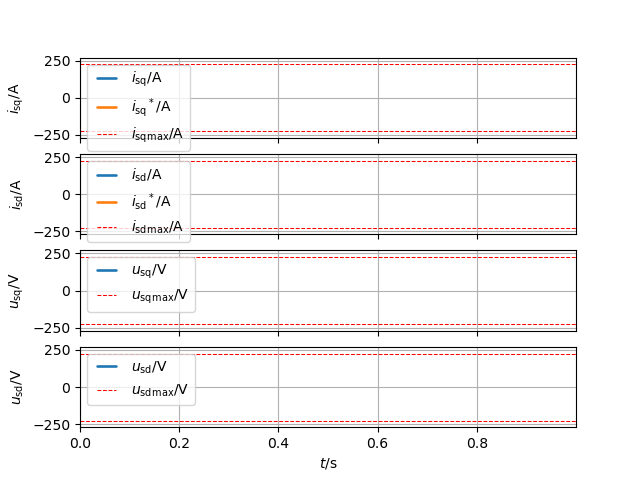

In [9]:
#%matplotlib notebook
%matplotlib widget
# use %matplotlib widget for execution in visual studio code
visu = MotorDashboard(state_plots=['i_sq', 'i_sd', 'u_sq', 'u_sd'], update_interval=10) # visualization
motor = Motor(MotorType.PermanentMagnetSynchronousMotor,
              ControlType.CurrentControl,
              ActionType.Continuous)
env = gem.make(motor.env_id(),
            visualization=visu,
            load=ConstantSpeedLoad(omega_fixed=1000 * np.pi / 30), # Fixed preset speed
            ode_solver=ScipySolveIvpSolver(), # ODE Solver of the simulation
            reference_generator=reference_generator, # initialize the reference generators
            
            # defenitions for the reward function
            reward_function=dict(
                reward_weights={'i_sq': 1, 'i_sd': 1},
                reward_power=0.5,
            ),
               
            # definitions for the setting parameters
            supply=dict(u_nominal=400),
            motor=dict(
                motor_parameter=motor_parameter,
                limit_values=limit_values,
                nominal_values=nominal_values
            )
    )

visu.initialize()

In [8]:
controller = Controller.make('fcs_mpc', env, ph=1) # initializing the MPC Controller
(state, reference), _ = env.reset()
cum_rew = 0

for i in range(10000): # simulate the PMSM for 10000 steps (1 second)
    env.render() # function for visualization
    action = controller.control(state, reference) # calculation of the manipulated variables
    (state, reference), reward, terminated, truncated, _ = env.step(action) # simulate one step of the PMSM
    cum_rew += reward # adding up the Reward 
    if terminated:
        (state, reference), _ = env.reset()
        controller.reset()
print('Reward =', cum_rew)
env.close()

Reward = -2059.299467864888
